<a href="https://colab.research.google.com/github/WuDianQiBian/ml-course/blob/master/notebooks/ch02_python_basics/sec09_matplotlib.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<p align="center">
  <img src="https://raw.githubusercontent.com/WuDianQiBian/ml-course/master/assets/banner.jpg" alt="五点七边 Logo" width="900"/>
</p>

# Matplotlib 数据可视化

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 在 Notebook 中内联显示图表
%matplotlib inline

# 设置默认图表大小和中文字体（macOS 用 Arial Unicode MS，Linux/Colab 可换成 SimHei）
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['figure.dpi'] = 100

## 1\. 折线图（Line Plot）

`plt.plot()` 是最基本的绑图函数，传入 x 和 y 即可。

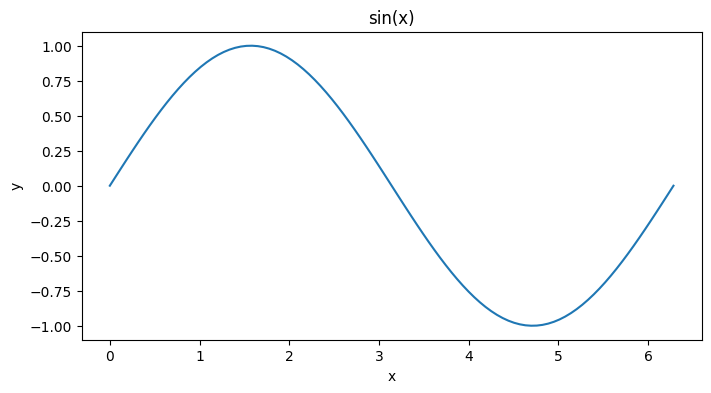

In [2]:
x = np.linspace(0, 2 * np.pi, 100)
y = np.sin(x)

plt.plot(x, y)
plt.title('sin(x)')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

同一张图上画多条曲线，并添加图例：

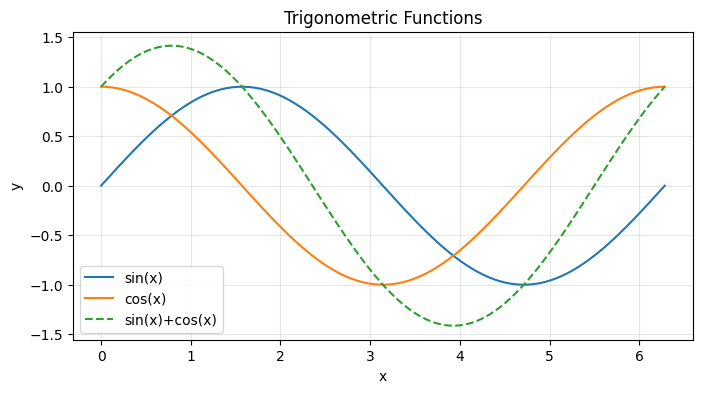

In [3]:
plt.plot(x, np.sin(x), label='sin(x)')
plt.plot(x, np.cos(x), label='cos(x)')
plt.plot(x, np.sin(x) + np.cos(x), label='sin(x)+cos(x)', linestyle='--')
plt.title('Trigonometric Functions')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 2\. 线型、颜色与标记（Style, Color, Marker）

可以通过参数自定义线条外观：颜色 (`color`)、线型 (`linestyle`)、标记 (`marker`)。

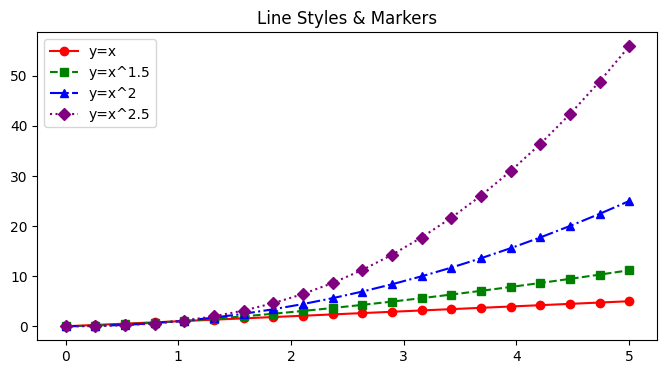

In [4]:
x = np.linspace(0, 5, 20)

plt.plot(x, x,      color='red',    linestyle='-',  marker='o', label='y=x')
plt.plot(x, x**1.5, color='green',  linestyle='--', marker='s', label='y=x^1.5')
plt.plot(x, x**2,   color='blue',   linestyle='-.', marker='^', label='y=x^2')
plt.plot(x, x**2.5, color='purple', linestyle=':',  marker='D', label='y=x^2.5')

plt.legend()
plt.title('Line Styles & Markers')
plt.show()

也可以用简写格式，如 `'ro--'` 表示红色、圆点标记、虚线：

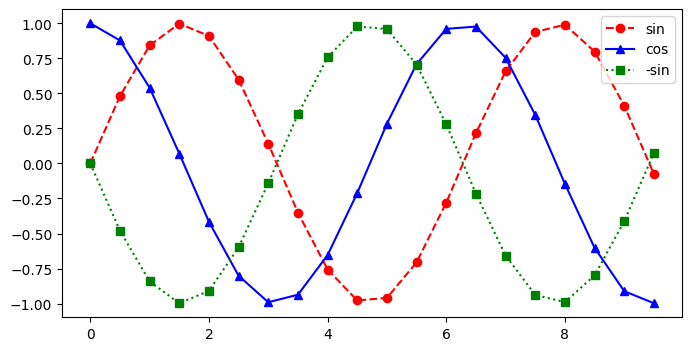

In [5]:
x = np.arange(0, 10, 0.5)

plt.plot(x, np.sin(x), 'ro--', label='sin')   # 红色-圆点-虚线
plt.plot(x, np.cos(x), 'b^-',  label='cos')   # 蓝色-三角-实线
plt.plot(x, -np.sin(x), 'gs:', label='-sin')   # 绿色-方块-点线
plt.legend()
plt.show()

## 3\. 散点图（Scatter Plot）

`plt.scatter()` 可以通过 `c`（颜色）和 `s`（大小）映射额外维度的数据。

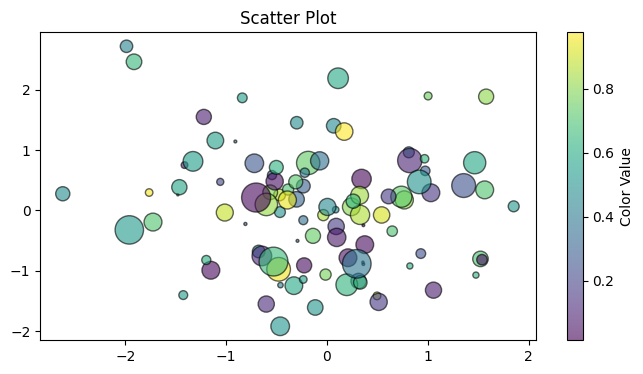

In [6]:
np.random.seed(42)
x = np.random.randn(100)
y = np.random.randn(100)
colors = np.random.rand(100)
sizes = np.abs(np.random.randn(100)) * 200

plt.scatter(x, y, c=colors, s=sizes, alpha=0.6, cmap='viridis', edgecolors='black')
plt.colorbar(label='Color Value')
plt.title('Scatter Plot')
plt.show()

散点图常用于展示分类数据：

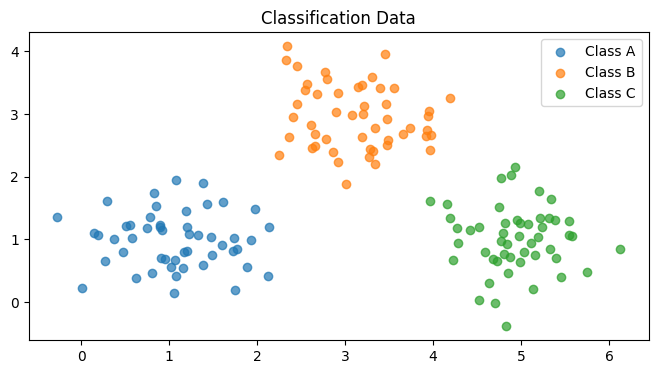

In [7]:
np.random.seed(0)

# 模拟三类数据
for i, (cx, cy, label) in enumerate([(1, 1, 'A'), (3, 3, 'B'), (5, 1, 'C')]):
    x = np.random.randn(50) * 0.5 + cx
    y = np.random.randn(50) * 0.5 + cy
    plt.scatter(x, y, label=f'Class {label}', alpha=0.7)

plt.legend()
plt.title('Classification Data')
plt.show()

## 4\. 柱状图（Bar Chart）

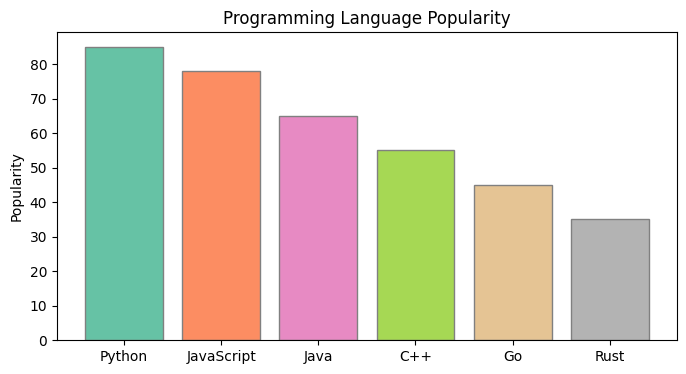

In [8]:
languages = ['Python', 'JavaScript', 'Java', 'C++', 'Go', 'Rust']
popularity = [85, 78, 65, 55, 45, 35]
colors = plt.cm.Set2(np.linspace(0, 1, len(languages)))

plt.bar(languages, popularity, color=colors, edgecolor='gray')
plt.ylabel('Popularity')
plt.title('Programming Language Popularity')
plt.show()

水平柱状图用 `plt.barh()`，分组柱状图通过偏移 x 坐标实现：

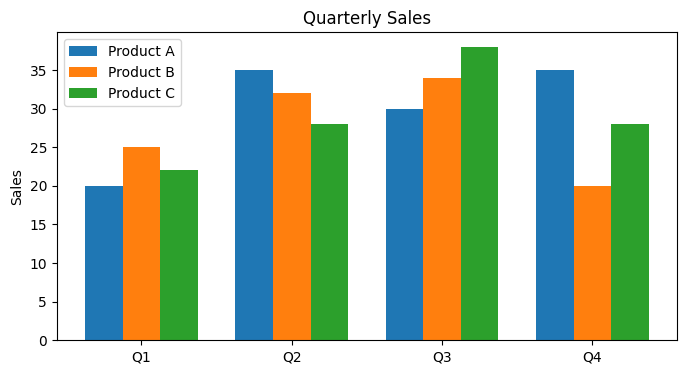

In [9]:
categories = ['Q1', 'Q2', 'Q3', 'Q4']
product_a = [20, 35, 30, 35]
product_b = [25, 32, 34, 20]
product_c = [22, 28, 38, 28]

x = np.arange(len(categories))
width = 0.25

plt.bar(x - width, product_a, width, label='Product A')
plt.bar(x,         product_b, width, label='Product B')
plt.bar(x + width, product_c, width, label='Product C')

plt.xticks(x, categories)
plt.ylabel('Sales')
plt.title('Quarterly Sales')
plt.legend()
plt.show()

堆叠柱状图用 `bottom` 参数：

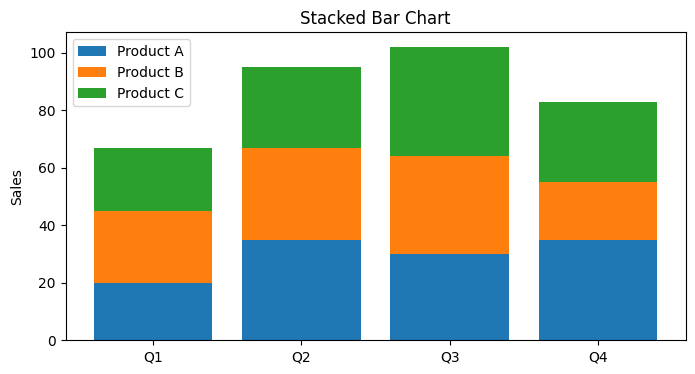

In [10]:
plt.bar(categories, product_a, label='Product A')
plt.bar(categories, product_b, bottom=product_a, label='Product B')
plt.bar(categories, product_c, bottom=np.array(product_a) + np.array(product_b), label='Product C')

plt.ylabel('Sales')
plt.title('Stacked Bar Chart')
plt.legend()
plt.show()

## 5\. 直方图（Histogram）

直方图用于展示数据分布，`bins` 控制分箱数量。

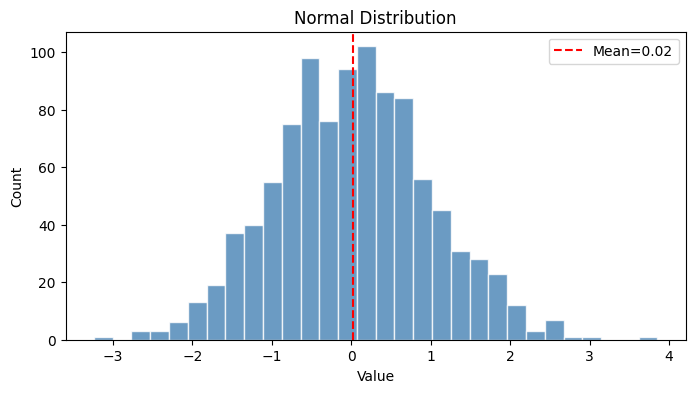

In [11]:
np.random.seed(42)
data = np.random.randn(1000)

plt.hist(data, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
plt.axvline(data.mean(), color='red', linestyle='--', label=f'Mean={data.mean():.2f}')
plt.title('Normal Distribution')
plt.xlabel('Value')
plt.ylabel('Count')
plt.legend()
plt.show()

多组数据叠加对比：

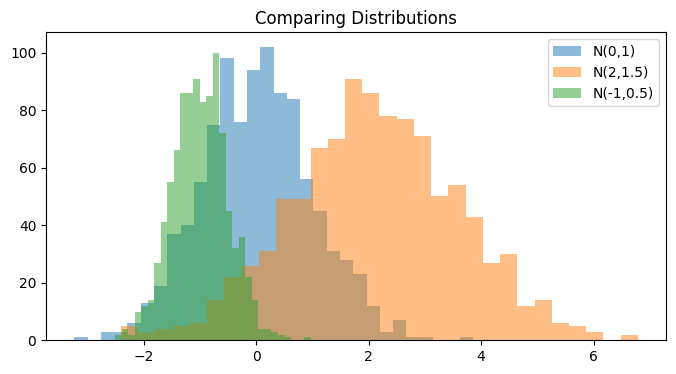

In [12]:
np.random.seed(42)
d1 = np.random.normal(0, 1, 1000)
d2 = np.random.normal(2, 1.5, 1000)
d3 = np.random.normal(-1, 0.5, 1000)

plt.hist(d1, bins=30, alpha=0.5, label='N(0,1)')
plt.hist(d2, bins=30, alpha=0.5, label='N(2,1.5)')
plt.hist(d3, bins=30, alpha=0.5, label='N(-1,0.5)')
plt.legend()
plt.title('Comparing Distributions')
plt.show()

## 6\. 饼图（Pie Chart）

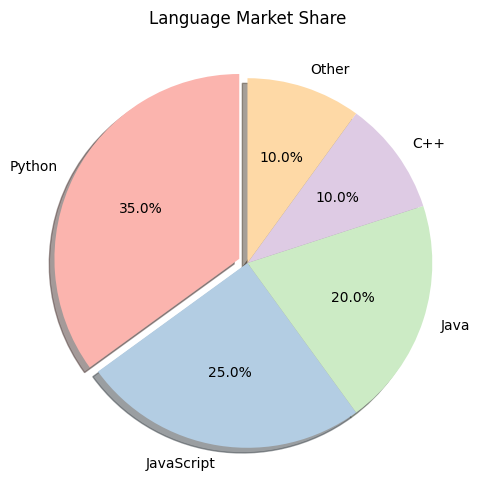

In [13]:
labels = ['Python', 'JavaScript', 'Java', 'C++', 'Other']
sizes = [35, 25, 20, 10, 10]
explode = (0.05, 0, 0, 0, 0)  # 突出显示第一块

plt.figure(figsize=(6, 6))
plt.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%',
        shadow=True, startangle=90, colors=plt.cm.Pastel1.colors[:5])
plt.title('Language Market Share')
plt.show()

## 7\. 子图（Subplots）

`plt.subplots()` 创建多个子图，返回 `fig` 和 `axes` 对象。

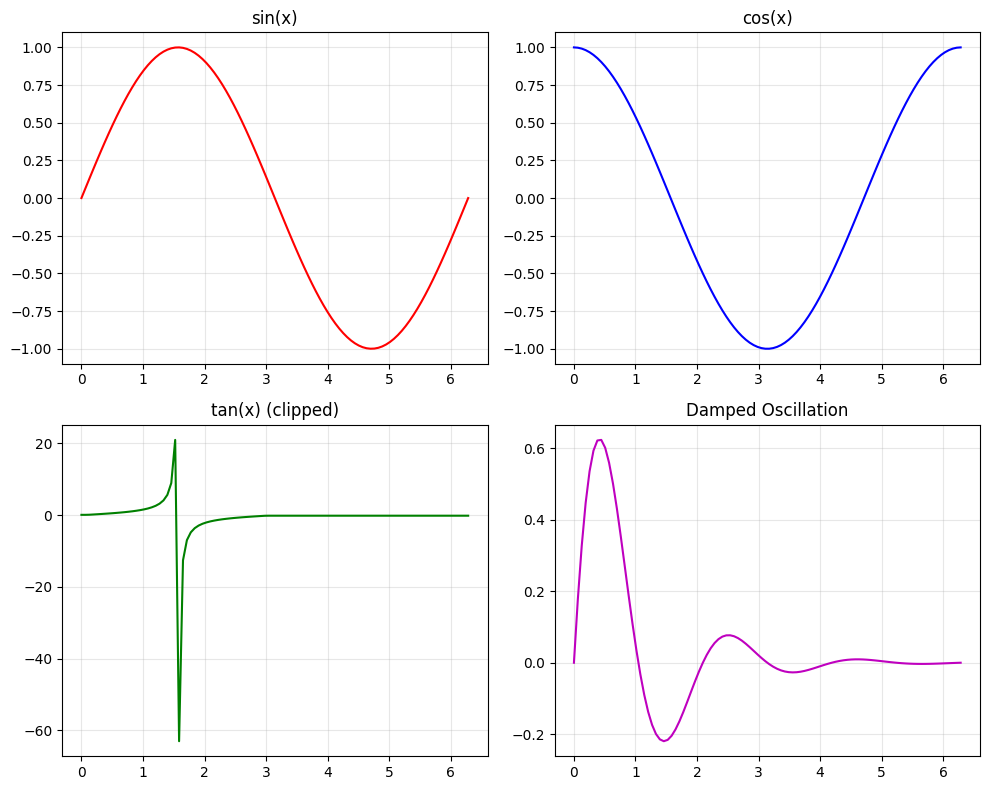

In [14]:
x = np.linspace(0, 2 * np.pi, 100)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].plot(x, np.sin(x), 'r-')
axes[0, 0].set_title('sin(x)')

axes[0, 1].plot(x, np.cos(x), 'b-')
axes[0, 1].set_title('cos(x)')

axes[1, 0].plot(x, np.tan(np.clip(x, 0.1, 3.0)), 'g-')
axes[1, 0].set_title('tan(x) (clipped)')

axes[1, 1].plot(x, np.exp(-x) * np.sin(3*x), 'm-')
axes[1, 1].set_title('Damped Oscillation')

for ax in axes.flat:
    ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

不同类型的图表也可以组合到子图中：

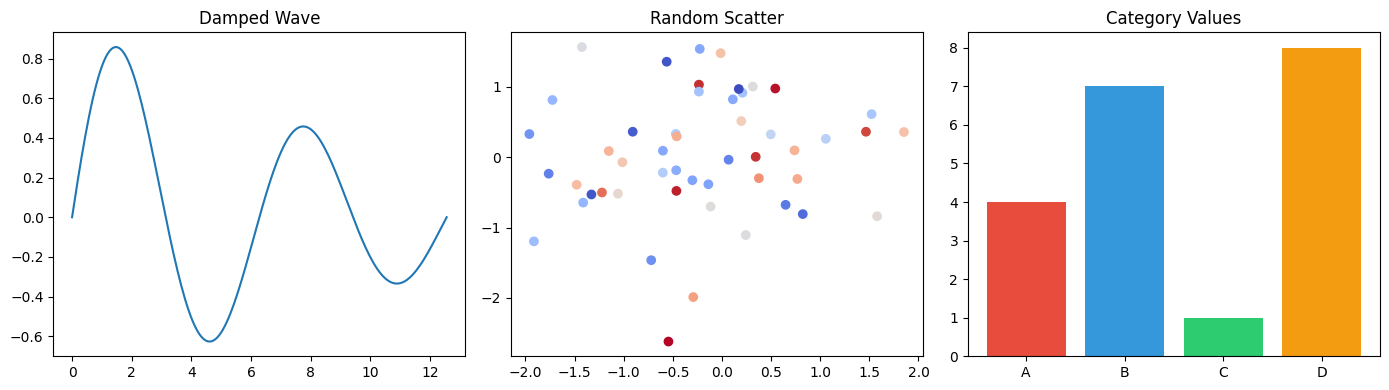

In [15]:
np.random.seed(42)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 子图 1: 折线图
t = np.linspace(0, 4*np.pi, 200)
axes[0].plot(t, np.sin(t) * np.exp(-0.1*t))
axes[0].set_title('Damped Wave')

# 子图 2: 散点图
axes[1].scatter(np.random.randn(50), np.random.randn(50), c=np.random.rand(50), cmap='coolwarm')
axes[1].set_title('Random Scatter')

# 子图 3: 柱状图
axes[2].bar(['A','B','C','D'], [4, 7, 1, 8], color=['#e74c3c','#3498db','#2ecc71','#f39c12'])
axes[2].set_title('Category Values')

fig.tight_layout()
plt.show()

## 8\. 填充区域与误差线（Fill & Error Bar）

`fill_between()` 填充两条曲线之间的区域，常用于展示置信区间。

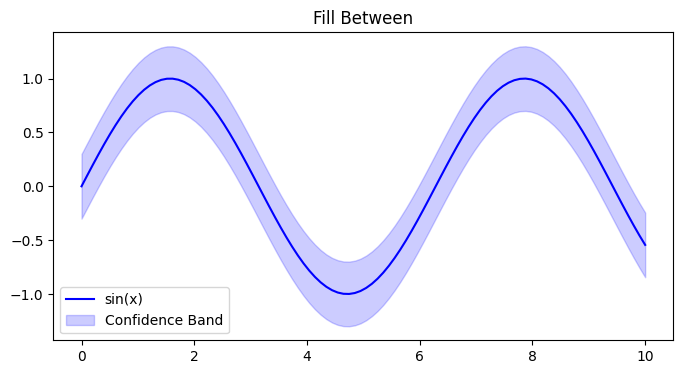

In [16]:
x = np.linspace(0, 10, 100)
y = np.sin(x)
y_upper = y + 0.3
y_lower = y - 0.3

plt.plot(x, y, 'b-', label='sin(x)')
plt.fill_between(x, y_lower, y_upper, alpha=0.2, color='blue', label='Confidence Band')
plt.legend()
plt.title('Fill Between')
plt.show()

误差线 `plt.errorbar()`：

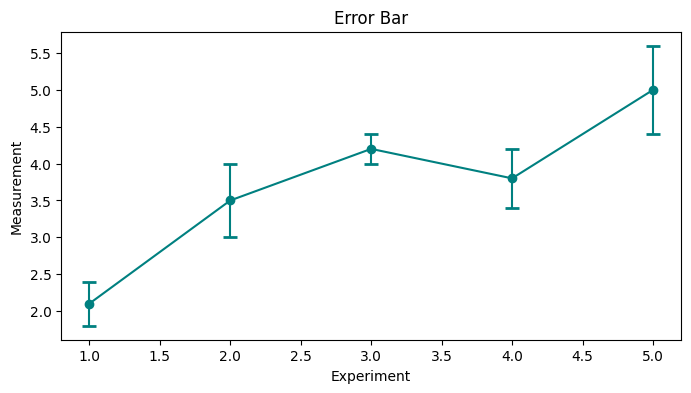

In [17]:
x = np.arange(1, 6)
y = [2.1, 3.5, 4.2, 3.8, 5.0]
errors = [0.3, 0.5, 0.2, 0.4, 0.6]

plt.errorbar(x, y, yerr=errors, fmt='o-', capsize=5, capthick=2, color='teal')
plt.title('Error Bar')
plt.xlabel('Experiment')
plt.ylabel('Measurement')
plt.show()

## 9\. 箱线图与小提琴图（Box & Violin Plot）

/var/folders/dc/qltvr6d939d3snyw2kq0njhm0000gn/T/ipykernel_12463/804346416.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(data, labels=labels, patch_artist=True)


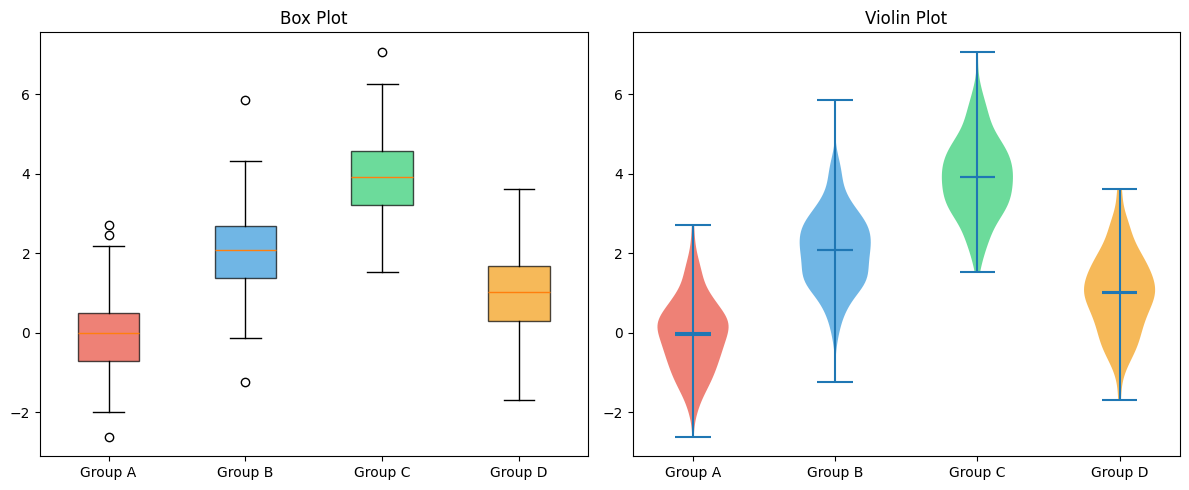

In [18]:
np.random.seed(42)
data = [np.random.normal(loc, 1, 200) for loc in [0, 2, 4, 1]]
labels = ['Group A', 'Group B', 'Group C', 'Group D']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 箱线图
bp = ax1.boxplot(data, labels=labels, patch_artist=True)
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax1.set_title('Box Plot')

# 小提琴图
vp = ax2.violinplot(data, showmeans=True, showmedians=True)
for i, body in enumerate(vp['bodies']):
    body.set_facecolor(colors[i])
    body.set_alpha(0.7)
ax2.set_xticks([1, 2, 3, 4])
ax2.set_xticklabels(labels)
ax2.set_title('Violin Plot')

fig.tight_layout()
plt.show()

## 10\. 热力图（Heatmap）

`plt.imshow()` 可以将二维数组可视化为热力图，常用于展示相关矩阵。

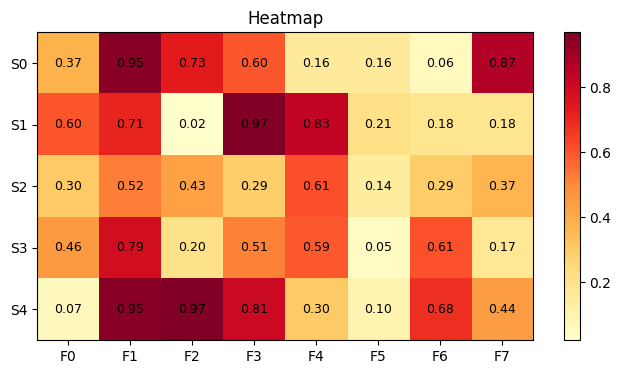

In [19]:
np.random.seed(42)
data = np.random.rand(5, 8)  # 模拟一个 5x8 的矩阵

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(data, cmap='YlOrRd', aspect='auto')

# 在每个格子中标注数值
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        ax.text(j, i, f'{data[i,j]:.2f}', ha='center', va='center', fontsize=9)

ax.set_xticks(range(8))
ax.set_yticks(range(5))
ax.set_xticklabels([f'F{i}' for i in range(8)])
ax.set_yticklabels([f'S{i}' for i in range(5)])
plt.colorbar(im)
plt.title('Heatmap')
plt.show()

相关系数矩阵热力图：

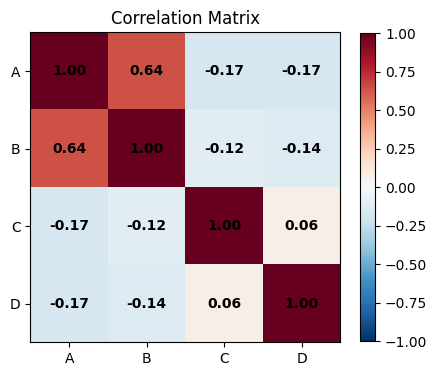

In [20]:
np.random.seed(42)
# 生成相关数据
a = np.random.randn(100)
b = a * 0.5 + np.random.randn(100) * 0.5
c = -a * 0.3 + np.random.randn(100) * 0.7
d = np.random.randn(100)
matrix = np.column_stack([a, b, c, d])
corr = np.corrcoef(matrix.T)
names = ['A', 'B', 'C', 'D']

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f'{corr[i,j]:.2f}', ha='center', va='center', fontweight='bold')
ax.set_xticks(range(4))
ax.set_yticks(range(4))
ax.set_xticklabels(names)
ax.set_yticklabels(names)
plt.colorbar(im, shrink=0.8)
plt.title('Correlation Matrix')
plt.show()

## 11\. 等高线图（Contour Plot）

等高线图展示三维曲面在二维平面上的投影。

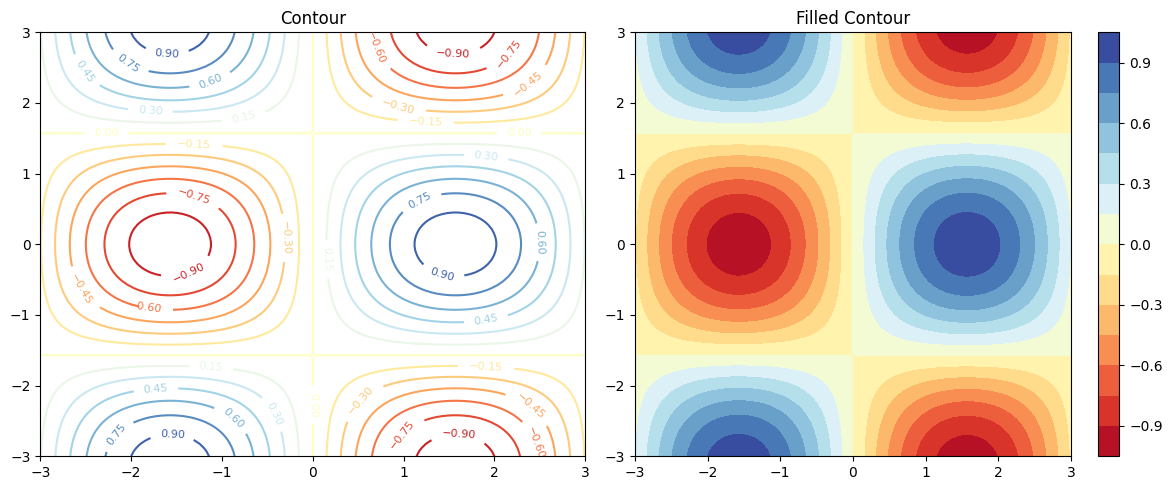

In [21]:
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)
Z = np.sin(X) * np.cos(Y)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 等高线
cs = ax1.contour(X, Y, Z, levels=15, cmap='RdYlBu')
ax1.clabel(cs, inline=True, fontsize=8)
ax1.set_title('Contour')

# 填充等高线
cf = ax2.contourf(X, Y, Z, levels=15, cmap='RdYlBu')
plt.colorbar(cf, ax=ax2)
ax2.set_title('Filled Contour')

fig.tight_layout()
plt.show()

## 12\. 3D 绑图

使用 `mpl_toolkits.mplot3d` 创建三维图形。

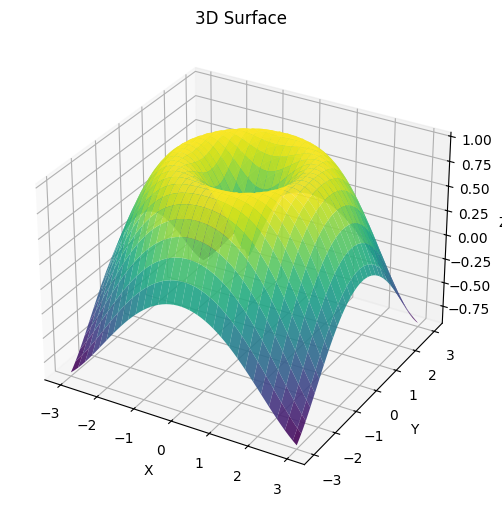

In [22]:
from mpl_toolkits.mplot3d import Axes3D

x = np.linspace(-3, 3, 60)
y = np.linspace(-3, 3, 60)
X, Y = np.meshgrid(x, y)
Z = np.sin(np.sqrt(X**2 + Y**2))

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.9)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Surface')
plt.show()

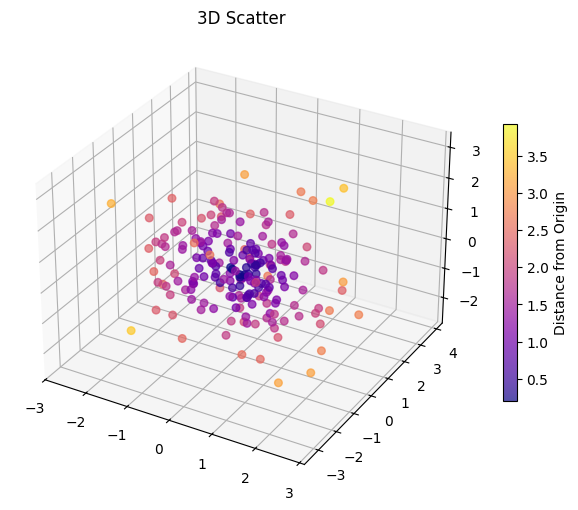

In [23]:
np.random.seed(42)
n = 200
x = np.random.randn(n)
y = np.random.randn(n)
z = np.random.randn(n)
colors = np.sqrt(x**2 + y**2 + z**2)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(x, y, z, c=colors, cmap='plasma', s=30, alpha=0.7)
plt.colorbar(sc, shrink=0.6, label='Distance from Origin')
ax.set_title('3D Scatter')
plt.show()

## 13\. 图像显示（imshow）

`plt.imshow()` 也常用于直接显示图像数据（NumPy 数组）。

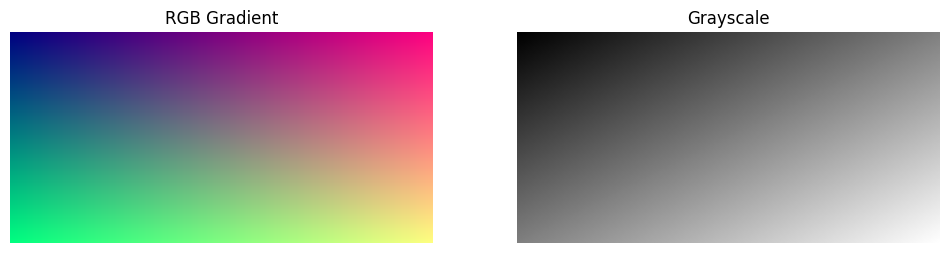

In [24]:
# 生成一张简单的渐变图像 (RGB)
img = np.zeros((100, 200, 3), dtype=np.uint8)
img[:, :, 0] = np.linspace(0, 255, 200).astype(np.uint8)   # R 通道水平渐变
img[:, :, 1] = np.linspace(0, 255, 100).astype(np.uint8)[:, None]  # G 通道垂直渐变
img[:, :, 2] = 128  # B 通道固定

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.imshow(img)
ax1.set_title('RGB Gradient')
ax1.axis('off')

# 转为灰度并显示
gray = img.mean(axis=2)
ax2.imshow(gray, cmap='gray')
ax2.set_title('Grayscale')
ax2.axis('off')

plt.show()

## 14\. 文本注释（Text & Annotation）

`plt.annotate()` 可以在图表上添加带箭头的注释。

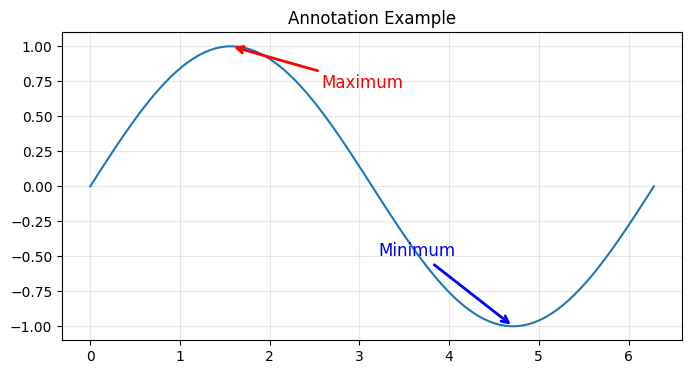

In [25]:
x = np.linspace(0, 2 * np.pi, 100)
y = np.sin(x)

plt.plot(x, y)

# 标注最大值
x_max = np.pi / 2
plt.annotate('Maximum', xy=(x_max, 1), xytext=(x_max + 1, 0.7),
             fontsize=12, color='red',
             arrowprops=dict(arrowstyle='->', color='red', lw=2))

# 标注最小值
x_min = 3 * np.pi / 2
plt.annotate('Minimum', xy=(x_min, -1), xytext=(x_min - 1.5, -0.5),
             fontsize=12, color='blue',
             arrowprops=dict(arrowstyle='->', color='blue', lw=2))

plt.title('Annotation Example')
plt.grid(True, alpha=0.3)
plt.show()

## 15\. 样式主题（Style Sheets）

Matplotlib 内置了多种样式主题，用 `plt.style.use()` 切换。

In [26]:
# 列出所有可用样式
print('Available styles:')
print(plt.style.available)

Available styles:
['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


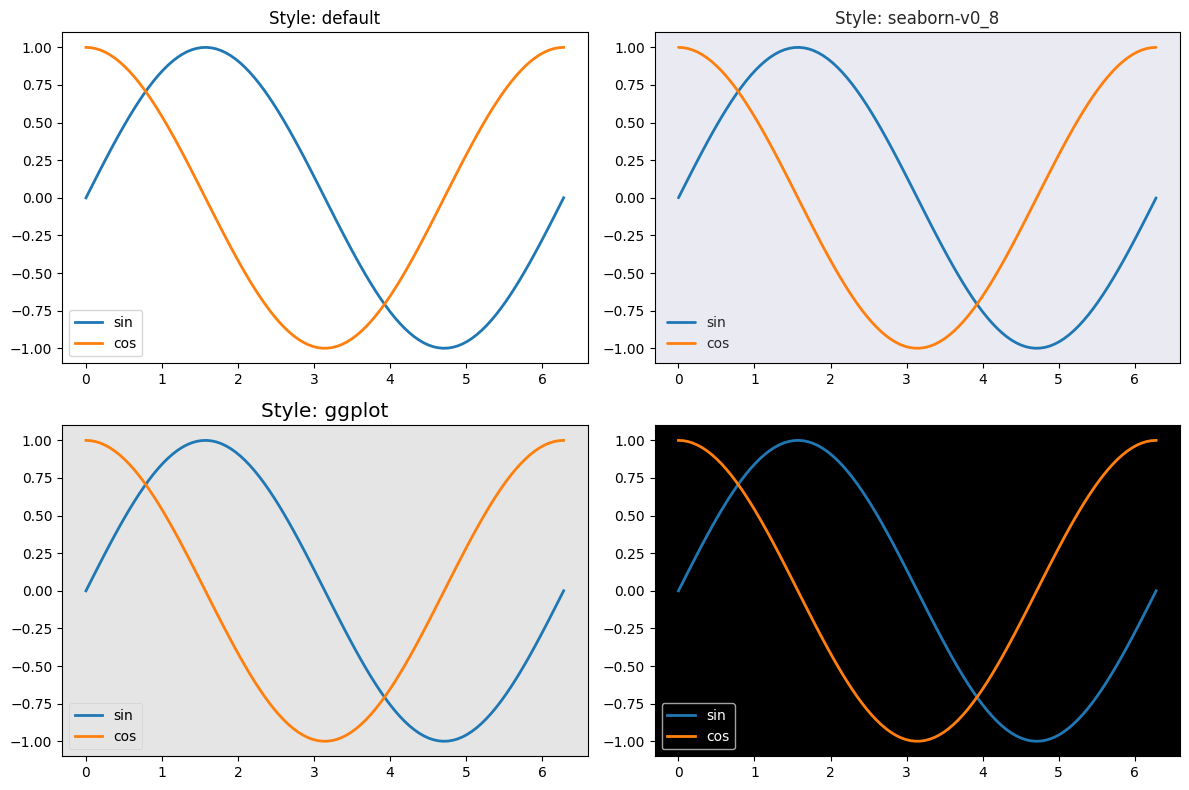

In [27]:
# 展示几种常用样式
x = np.linspace(0, 2*np.pi, 100)
styles = ['default', 'seaborn-v0_8', 'ggplot', 'dark_background']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, style_name in zip(axes.flat, styles):
    with plt.style.context(style_name):
        # style.context 不影响已创建的 axes，手动设置背景色
        style_dict = plt.style.library.get(style_name, {})
        bg = style_dict.get('axes.facecolor', 'white')
        fg = style_dict.get('text.color', 'black')
        ax.set_facecolor(bg)
        ax.plot(x, np.sin(x), label='sin', linewidth=2)
        ax.plot(x, np.cos(x), label='cos', linewidth=2)
        ax.set_title(f'Style: {style_name}', color=fg)
        ax.legend()

fig.tight_layout()
plt.show()

## 16\. 对数坐标与双轴图

对数坐标适合展示跨多个数量级的数据。

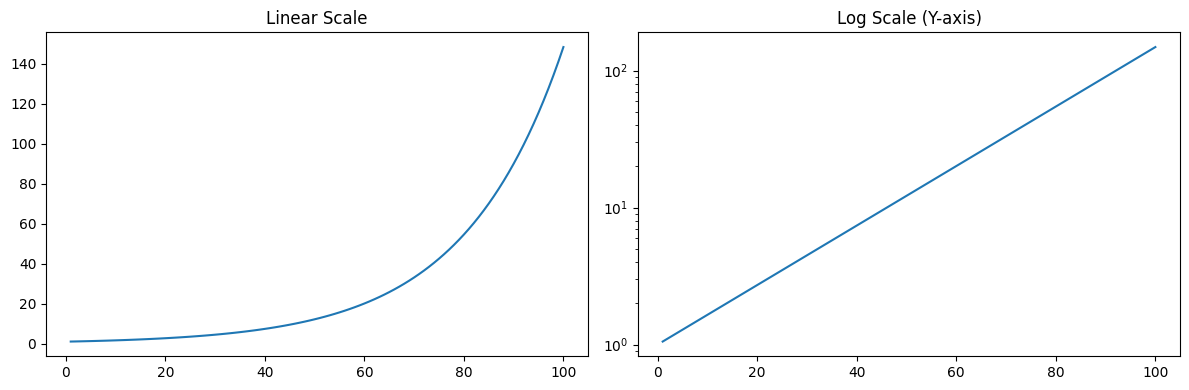

In [28]:
x = np.linspace(1, 100, 100)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# 普通坐标
ax1.plot(x, np.exp(x / 20))
ax1.set_title('Linear Scale')

# 对数坐标
ax2.plot(x, np.exp(x / 20))
ax2.set_yscale('log')
ax2.set_title('Log Scale (Y-axis)')

fig.tight_layout()
plt.show()

双 Y 轴用 `ax.twinx()`，适合同时展示不同量纲的数据：

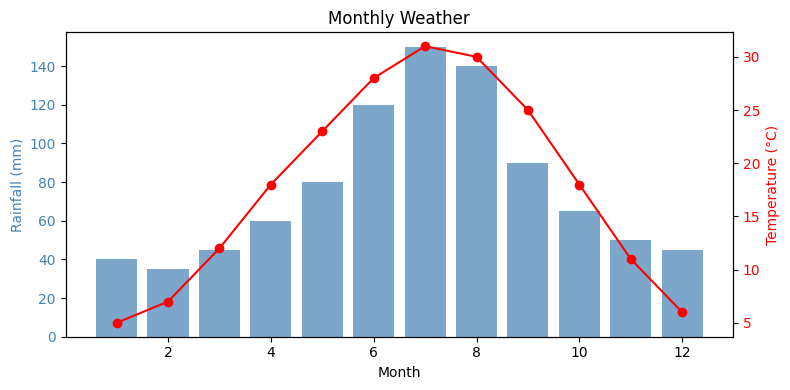

In [29]:
months = np.arange(1, 13)
temperature = [5, 7, 12, 18, 23, 28, 31, 30, 25, 18, 11, 6]
rainfall = [40, 35, 45, 60, 80, 120, 150, 140, 90, 65, 50, 45]

fig, ax1 = plt.subplots(figsize=(8, 4))

ax1.bar(months, rainfall, color='steelblue', alpha=0.7, label='Rainfall (mm)')
ax1.set_xlabel('Month')
ax1.set_ylabel('Rainfall (mm)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(months, temperature, 'ro-', label='Temperature')
ax2.set_ylabel('Temperature (°C)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Monthly Weather')
fig.tight_layout()
plt.show()

## 17\. 极坐标图（Polar Plot）

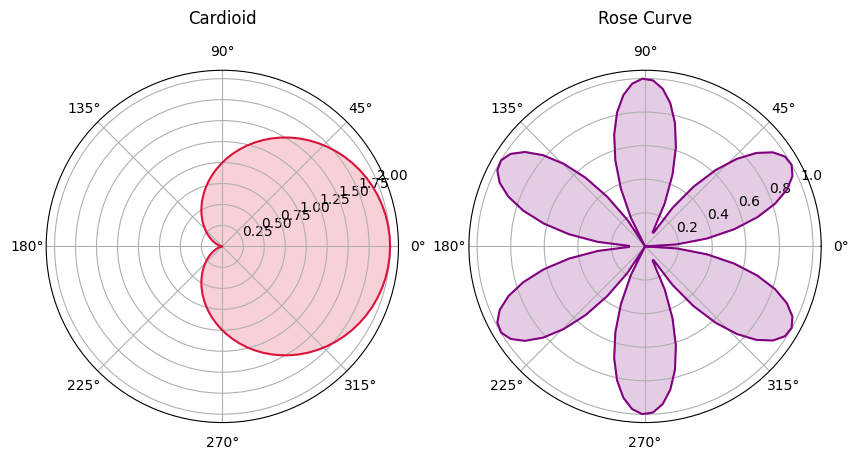

In [30]:
theta = np.linspace(0, 2*np.pi, 100)
r1 = 1 + np.cos(theta)          # 心形线
r2 = np.abs(np.sin(3 * theta))  # 三叶玫瑰线

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), subplot_kw={'projection': 'polar'})

ax1.plot(theta, r1, color='crimson')
ax1.fill(theta, r1, alpha=0.2, color='crimson')
ax1.set_title('Cardioid', pad=15)

ax2.plot(theta, r2, color='purple')
ax2.fill(theta, r2, alpha=0.2, color='purple')
ax2.set_title('Rose Curve', pad=15)

plt.show()

雷达图（Radar Chart）是极坐标的常见应用：

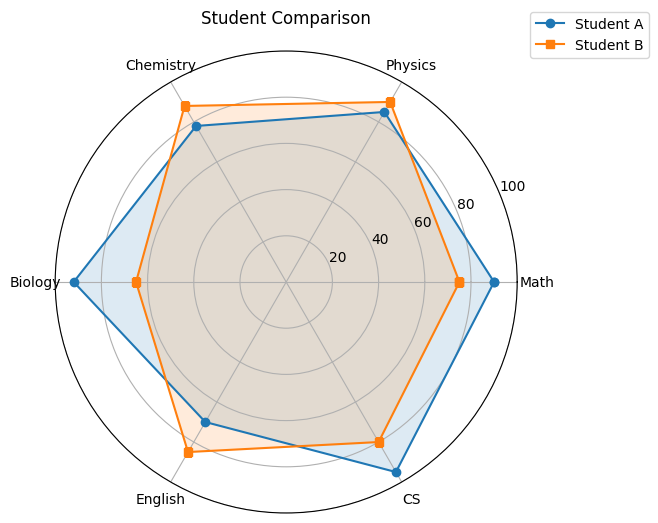

In [31]:
categories = ['Math', 'Physics', 'Chemistry', 'Biology', 'English', 'CS']
student_a = [90, 85, 78, 92, 70, 95]
student_b = [75, 90, 88, 65, 85, 80]

# 闭合多边形
angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist()
student_a += student_a[:1]
student_b += student_b[:1]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={'projection': 'polar'})
ax.plot(angles, student_a, 'o-', label='Student A')
ax.fill(angles, student_a, alpha=0.15)
ax.plot(angles, student_b, 's-', label='Student B')
ax.fill(angles, student_b, alpha=0.15)
ax.set_thetagrids(np.degrees(angles[:-1]), categories)
ax.set_ylim(0, 100)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.set_title('Student Comparison', pad=20)
plt.show()

## 18\. 保存图表

`plt.savefig()` 支持多种格式：PNG、PDF、SVG 等。注意要在 `plt.show()` 之前调用。

Uncomment savefig lines above to actually save files.


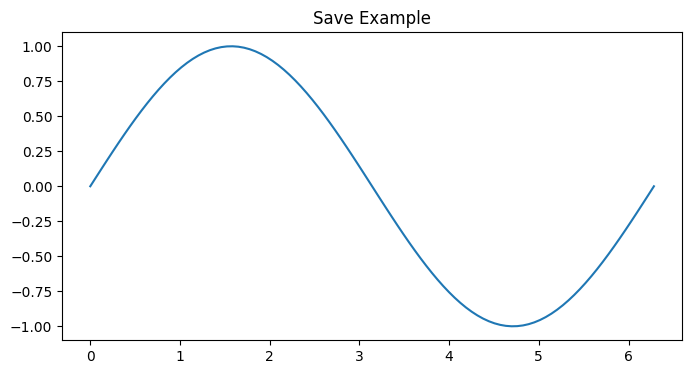

In [32]:
x = np.linspace(0, 2*np.pi, 100)
fig, ax = plt.subplots()
ax.plot(x, np.sin(x))
ax.set_title('Save Example')

# 保存为 PNG（高分辨率）
# fig.savefig('my_plot.png', dpi=200, bbox_inches='tight')

# 保存为 PDF（矢量图，适合论文）
# fig.savefig('my_plot.pdf', bbox_inches='tight')

print('Uncomment savefig lines above to actually save files.')
plt.show()